**Dataset Link => https://www.kaggle.com/datasets/swarupsudulaganti/uk-house-price-prediction-dataset-2015-to-2024**

In [1]:
import os
import shutil

In [2]:
import kaggle

kaggle.api.authenticate()

kaggle.api.dataset_download_files('swarupsudulaganti/uk-house-price-prediction-dataset-2015-to-2024', path='new_dataset', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/swarupsudulaganti/uk-house-price-prediction-dataset-2015-to-2024


## **Libraries**

In [133]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from category_encoders import CatBoostEncoder
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
import joblib

## **Loading Data**

In [112]:
data = pd.read_csv('new_dataset/UK_House_Price_Prediction_dataset_2015_to_2024.csv')
data.head()

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
0,735000,2017-08-07,LE17 5AP,D,N,F,CLAYBROOKE COURT,CLAYBROOKE PARVA,LUTTERWORTH,HARBOROUGH,LEICESTERSHIRE
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY,MEDWAY
3,625000,2021-10-13,RH20 3EU,D,N,F,LINFIELD COPSE,THAKEHAM,PULBOROUGH,HORSHAM,WEST SUSSEX
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE,WILTSHIRE


In [113]:
data = data.sort_values(by='date')
data.head()

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
85391,310000,2015-01-02,TN21 9HJ,S,N,F,NORTH CORNER,HORAM,HEATHFIELD,WEALDEN,EAST SUSSEX
17138,85000,2015-01-02,NG17 7EH,T,N,F,KINGSWAY,KIRKBY IN ASHFIELD,NOTTINGHAM,ASHFIELD,NOTTINGHAMSHIRE
36568,235000,2015-01-02,NG23 7LD,D,N,F,DYKES END,COLLINGHAM,NEWARK,NEWARK AND SHERWOOD,NOTTINGHAMSHIRE
47608,368000,2015-01-02,L37 3NU,D,N,L,GORES LANE,FORMBY,LIVERPOOL,SEFTON,MERSEYSIDE
67452,365500,2015-01-05,EN8 9RX,S,N,F,GIBBS CLOSE,CHESHUNT,WALTHAM CROSS,BROXBOURNE,HERTFORDSHIRE


### Basic Info

In [114]:
print(f"The dataset has {data.shape[0]} rows/records and {data.shape[1]} columns")

The dataset has 90000 rows/records and 11 columns


In [115]:
print(f"The dataset has columns namely \n{data.columns.to_list()}")

The dataset has columns namely 
['price', 'date', 'postcode', 'property_type', 'new_build', 'freehold', 'street', 'locality', 'town', 'district', 'county']


## **Visualization**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Property_Type vs. FreeHold/LeaseHold
plt.figure(figsize=(10, 6))
sns.countplot(data=X, x='property_type', hue='freehold')
plt.title('Count of Property Types by Tenure')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=X, x='new_build', hue='freehold')
plt.title('Count of Condition by Tenure')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=X, x='property_type', hue='new_build')
plt.title('Count of Property Types by Condition')
plt.show()

## **Data Cleaning & Feature Engineering**

**Remove Suplicates**

In [116]:
data.duplicated().sum()

np.int64(43)

In [117]:
data.drop_duplicates(keep='first', inplace=True)

**Convert date and Extract Features**

In [118]:
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['quarter'] = data['date'].dt.quarter

**Create hierarchical location features**

In [119]:
data['postcode_area'] = data['postcode'].str.split().str[0]
data['town_district'] = data['town'] + '_' + data['district']
data['district_county'] = data['district'] + '_' + data['county']

**Map property types to readable values**

In [120]:
property_map = {
    'D': 'Detached',
    'S': 'Semi-Detached',
    'T': 'Terrace',
    'F': 'Flat',
    'O': 'Other'
}
data['property_type'] = data['property_type'].map(property_map)

**Binary Flags for Columns**

In [121]:
data['is_freehold'] = data['freehold'].apply(lambda x: 1 if x == 'Y' else 0)
data['is_newbuild'] = data['new_build'].apply(lambda x: 1 if x == 'Y' else 0)

**Dropping Columns**

In [122]:
# Drop unnecessary columns
cols_to_drop = ['date', 'postcode', 'street', 'locality', 'freehold', 'new_build']
data.drop(cols_to_drop, axis=1, inplace=True)

## **Target Transformation and Outlier Removal**

In [123]:
# Log-transform the target variable
data['log_price'] = np.log1p(data['price'])

In [124]:
# Remove extreme outliers (top/bottom 1%)
lower = data['price'].quantile(0.01)
upper = data['price'].quantile(0.99)
data = data[(data['price'] >= lower) & (data['price'] <= upper)]

## **Train-Test Split and Feature Encoding**

In [125]:
# Define features and target
X = data.drop(['price', 'log_price'], axis=1)
y = data['log_price']  # Using log-transformed price as target

In [126]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [127]:
# Identify column types
low_card_cols = ['property_type', 'quarter', 'month']
high_card_cols = ['town', 'district', 'county', 'postcode_area', 'town_district', 'district_county']

In [128]:
# CatBoost encoding for high cardinality features
cbe = CatBoostEncoder(cols=high_card_cols, sigma=0.1)
X_train[high_card_cols] = cbe.fit_transform(X_train[high_card_cols], y_train)
X_test[high_card_cols] = cbe.transform(X_test[high_card_cols])

In [129]:
# One-hot encode low cardinality features
X_train = pd.get_dummies(X_train, columns=low_card_cols)
X_test = pd.get_dummies(X_test, columns=low_card_cols)

In [130]:
# Ensure both sets have same columns
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
X_test = X_test[X_train.columns]

## **Model Training with Hyperparameter Tuning**

In [170]:
X_train.shape

(70542, 30)

**LightBGM**

In [ ]:
lgb_params = {
    'learning_rate': [0.01, 0.05],
    'n_estimators': [500, 800],
    'num_leaves': [31, 63],
    'min_child_samples': [20, 50],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1]
}

lgb = LGBMRegressor(random_state=42, verbose=-1)
lgb_cv = GridSearchCV(lgb, lgb_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lgb_cv.fit(X_train, y_train)

,estimator,"LGBMRegressor...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05], 'min_child_samples': [20, 50], 'n_estimators': [500, 800], 'num_leaves': [31, 63], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


**XGBoost**

In [ ]:
# XGBoost with grid search
xgb_params = {
    'learning_rate': [0.01, 0.05],
    'n_estimators': [500, 800],
    'max_depth': [5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
xgb_cv = GridSearchCV(xgb, xgb_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
xgb_cv.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05], 'max_depth': [5, 7], 'n_estimators': [500, 800], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


**Decision Tree Regressor**

In [ ]:
dt_params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2', 0.8]
}

dt = DecisionTreeRegressor(random_state=42)
dt_cv = GridSearchCV(dt, dt_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, error_score='raise')
dt_cv.fit(X_train, y_train)

e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
  File "e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\base.py", line 469, in _validate_params
    validate_parameter_constraints(
 

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


**Random Forest Regressor**

In [ ]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', 0.8]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, error_score='raise')
rf_cv.fit(X_train, y_train)

e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
  File "e:\Free Lancing\URL\Real Estate\renv\Lib\site-packages\sklearn\base.py", line 469, in _validate_params
    validate_parameter_constraints(


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


## **Model Evaluation**

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred = np.expm1(y_pred)  # Convert back from log scale
    y_true = np.expm1(y_test)
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"MAE: £{mae:,.2f}")
    print(f"R²: {r2:.3f}")
    print(f"RMSE: £{rmse:,.2f}")
    
    return {'MAE': mae, 'R2': r2, 'RMSE': rmse}


In [148]:
print("LightGBM Results:")
lgb_results = evaluate_model(lgb_cv.best_estimator_, X_test, y_test)

LightGBM Results:
MAE: £97,808.77
R²: 0.308
RMSE: £157,286.31


In [149]:
print("\nXGBoost Results:")
xgb_results = evaluate_model(xgb_cv.best_estimator_, X_test, y_test)


XGBoost Results:
MAE: £98,764.26
R²: 0.303
RMSE: £157,764.21


In [150]:
print("\nDecision Tree Best Parameters:", dt_cv.best_params_)
print("Decision Tree Results:")
dt_results = evaluate_model(dt_cv.best_estimator_, X_test, y_test)


Decision Tree Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree Results:
MAE: £112,503.56
R²: 0.149
RMSE: £174,401.57


In [151]:
print("\nRandom Forest Best Parameters:", rf_cv.best_params_)
print("Random Forest Results:")
rf_results = evaluate_model(rf_cv.best_estimator_, X_test, y_test)


Random Forest Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest Results:
MAE: £99,658.08
R²: 0.294
RMSE: £158,861.02


### Ensemble Model

In [152]:
voting = VotingRegressor([
    ('lgb', lgb_cv.best_estimator_),
    ('xgb', xgb_cv.best_estimator_),
    ('dtr', dt_cv.best_estimator_),
    ('rtr', rf_cv.best_estimator_),
])
voting.fit(X_train, y_train)

print("\nVoting Regressor Results:")
voting_results = evaluate_model(voting, X_test, y_test)


Voting Regressor Results:
MAE: £100,167.82
R²: 0.277
RMSE: £160,733.25


### Feature Importance Analysis

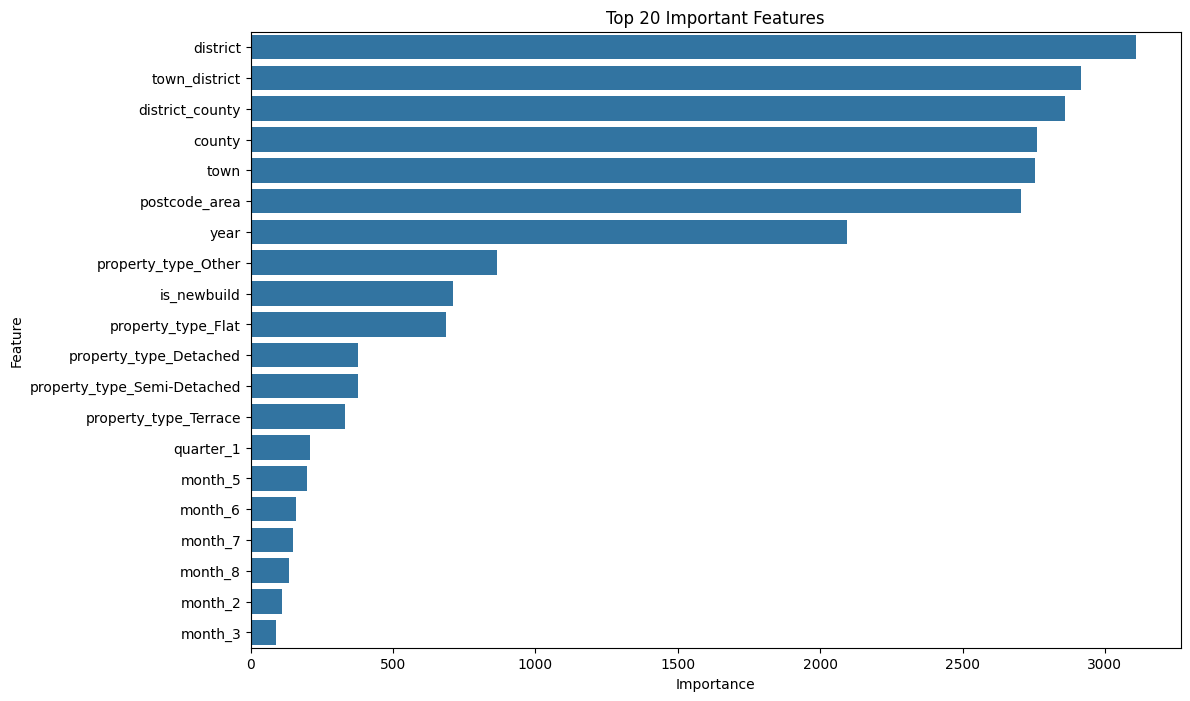

In [153]:
lgb = lgb_cv.best_estimator_
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20))
plt.title('Top 20 Important Features')
plt.show()

### Results

In [161]:
results = {
    'Decision Tree': dt_results,
    'Random Forest': rf_results,
    'XGBoost': xgb_results,
    'LightGBM': lgb_results,
    'Ensemble (Voting)': voting_results
}

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('MAE', ascending=False)

print("\n===== Final Model Comparison =====")
print(results_df)


===== Final Model Comparison =====
                             MAE        R2           RMSE
Decision Tree      112503.562843  0.148752  174401.570513
Ensemble (Voting)  100167.818623  0.276952  160733.251212
Random Forest       99658.083987  0.293698  158861.022079
XGBoost             98764.260205  0.303418  157764.211920
LightGBM            97808.766111  0.307631  157286.308292


### Saving Models

In [169]:
# Save models
joblib.dump(lgb_cv.best_estimator_, 'lgb_model.pkl')
joblib.dump(xgb_cv.best_estimator_, 'xgb_model.pkl')

# Save encoders
joblib.dump(cbe, 'catboost_encoder.pkl')

# Save column names
joblib.dump(list(X_train.columns), 'feature_columns.pkl')

print("All models and encoders saved successfully!")

All models and encoders saved successfully!


### Visualization of Results

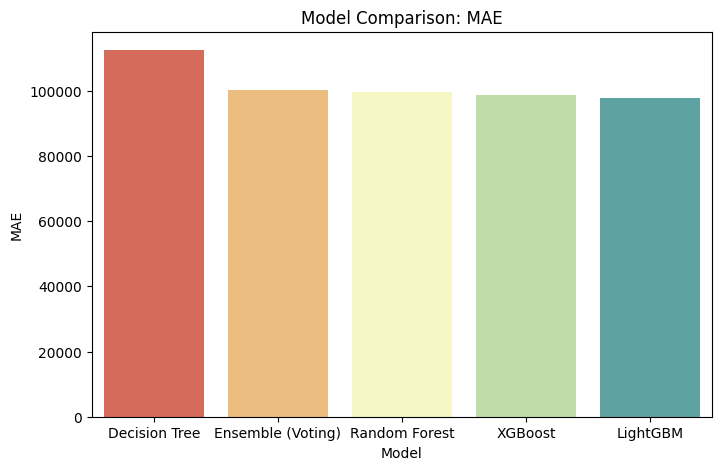

In [167]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x=results_df.index, y="MAE", hue=results_df.index, palette='Spectral')
plt.title("Model Comparison: MAE")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()

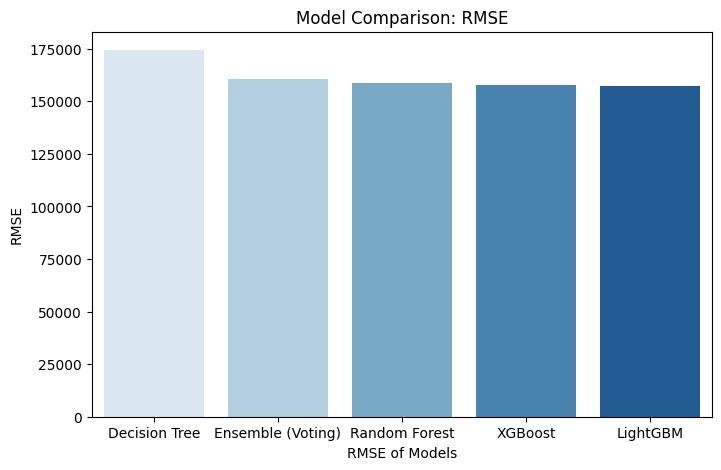

In [165]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x=results_df.index, y="RMSE", hue=results_df.index, palette='Blues')
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xlabel("RMSE of Models")
plt.show()

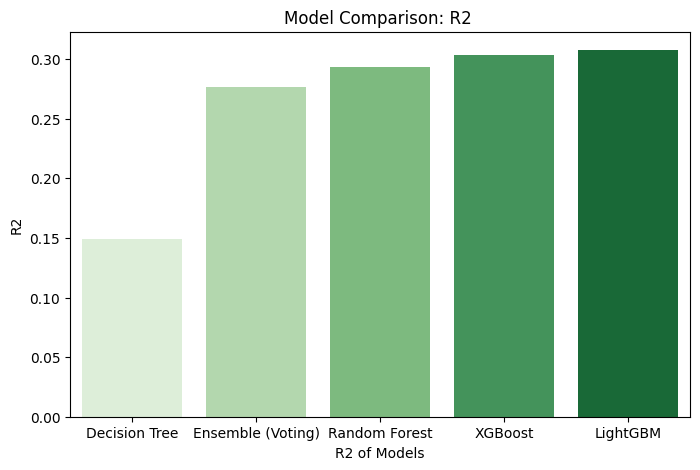

In [168]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x=results_df.index, y="R2", hue=results_df.index, palette='Greens')
plt.title("Model Comparison: R2 ")
plt.ylabel("R2")
plt.xlabel("R2 of Models")
plt.show()